In [3]:
import os
import sys
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

In [4]:
# z zadania 1

import functools
from datasets import load_dataset

@functools.lru_cache(maxsize=4)
def get_imdb_subset(split: str, n: int):
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

samples = get_imdb_subset("train", 2000)

In [5]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
    .appName("Lab 5 Window Functions")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark {spark.version} ready")

samples_spark = get_imdb_subset("train", 2000)
rows = [(i, text, label) for i, (text, label) in enumerate(samples_spark)]

df = spark.createDataFrame(rows, ["id", "text", "label"])

df_words = (df
    .withColumn("clean_text", F.lower(F.regexp_replace("text", r"<[^>]+>", " ")))
    .withColumn("words", F.split("clean_text", r"\W+"))
    .withColumn("word_count", F.size("words"))
)

print("\nPodgląd danych z word_count:")
df_words.select("id", "label", "word_count").show(10)

Spark 4.0.3 ready

Podgląd danych z word_count:
+---+-----+----------+
| id|label|word_count|
+---+-----+----------+
|  0|    1|       127|
|  1|    1|       133|
|  2|    0|       185|
|  3|    1|       123|
|  4|    0|       664|
|  5|    1|       208|
|  6|    1|       120|
|  7|    0|       171|
|  8|    0|       313|
|  9|    1|       252|
+---+-----+----------+
only showing top 10 rows


In [7]:
#ranking recenzji
window_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())

df_ranked = df_words.withColumn(
    "ranking",
    F.row_number().over(window_rank)
)

print("Ranking recenzji w obrębie klasy:")
df_ranked.select("id", "label", "word_count", "ranking").show(10)

Ranking recenzji w obrębie klasy:
+----+-----+----------+-------+
|  id|label|word_count|ranking|
+----+-----+----------+-------+
| 518|    0|      1020|      1|
|1869|    0|      1018|      2|
| 566|    0|      1014|      3|
|1811|    0|       987|      4|
|1393|    0|       986|      5|
|1339|    0|       966|      6|
|1769|    0|       941|      7|
|1413|    0|       934|      8|
|  31|    0|       906|      9|
| 508|    0|       901|     10|
+----+-----+----------+-------+
only showing top 10 rows


In [8]:
#3 najdłuższe recenzje
top3 = df_ranked.filter(F.col("ranking") <= 3)

print("Top 3 najdłuższe recenzje dla każdej klasy:")
top3.select("id", "label", "word_count", "ranking").orderBy("label", "ranking").show()

Top 3 najdłuższe recenzje dla każdej klasy:
+----+-----+----------+-------+
|  id|label|word_count|ranking|
+----+-----+----------+-------+
| 518|    0|      1020|      1|
|1869|    0|      1018|      2|
| 566|    0|      1014|      3|
|1109|    1|      1000|      1|
|1526|    1|       998|      2|
|1557|    1|       996|      3|
+----+-----+----------+-------+



In [10]:
#różnica od średniej długości w klasie
window_label = Window.partitionBy("label")

df_with_avg = df_ranked.withColumn(
    "avg_word_count_class",
    F.avg("word_count").over(window_label)
).withColumn(
    "diff_from_avg",
    F.col("word_count") - F.col("avg_word_count_class")
)

print("Różnica długości recenzji od średniej w klasie:")
df_with_avg.select(
    "id",
    "label",
    "word_count",
    F.round("avg_word_count_class", 2).alias("avg_word_count_class"),
    F.round("diff_from_avg", 2).alias("diff_from_avg")
).show(10)

Różnica długości recenzji od średniej w klasie:
+---+-----+----------+--------------------+-------------+
| id|label|word_count|avg_word_count_class|diff_from_avg|
+---+-----+----------+--------------------+-------------+
|  2|    0|       185|              230.52|       -45.52|
|  4|    0|       664|              230.52|       433.48|
|  7|    0|       171|              230.52|       -59.52|
|  8|    0|       313|              230.52|        82.48|
| 11|    0|       186|              230.52|       -44.52|
| 12|    0|       161|              230.52|       -69.52|
| 13|    0|       167|              230.52|       -63.52|
| 16|    0|       178|              230.52|       -52.52|
| 17|    0|       195|              230.52|       -35.52|
| 20|    0|       169|              230.52|       -61.52|
+---+-----+----------+--------------------+-------------+
only showing top 10 rows


In [11]:
#moving average z ostatnich 50 recenzji w obrębie klasy
window_moving = (
    Window.partitionBy("label")
    .orderBy("id")
    .rowsBetween(-49, 0)
)

df_moving = df_with_avg.withColumn(
    "moving_avg_50",
    F.avg("word_count").over(window_moving)
)

print("Moving average dla okna 50 ostatnich recenzji:")
df_moving.select(
    "id",
    "label",
    "word_count",
    F.round("moving_avg_50", 2).alias("moving_avg_50")
).orderBy("label", "id").show(20)

Moving average dla okna 50 ostatnich recenzji:
+---+-----+----------+-------------+
| id|label|word_count|moving_avg_50|
+---+-----+----------+-------------+
|  2|    0|       185|        185.0|
|  4|    0|       664|        424.5|
|  7|    0|       171|        340.0|
|  8|    0|       313|       333.25|
| 11|    0|       186|        303.8|
| 12|    0|       161|        280.0|
| 13|    0|       167|       263.86|
| 16|    0|       178|       253.13|
| 17|    0|       195|       246.67|
| 20|    0|       169|        238.9|
| 21|    0|       148|       230.64|
| 22|    0|       299|       236.33|
| 24|    0|       760|       276.62|
| 26|    0|       203|       271.36|
| 30|    0|       326|        275.0|
| 31|    0|       906|       314.44|
| 33|    0|       129|       303.53|
| 34|    0|       191|       297.28|
| 36|    0|       660|       316.37|
| 37|    0|       130|       307.05|
+---+-----+----------+-------------+
only showing top 20 rows


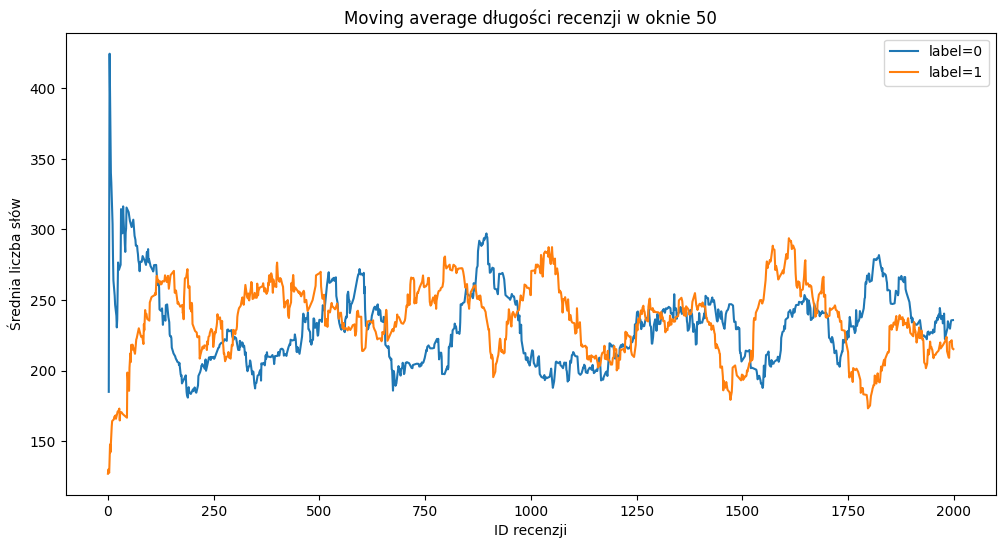

In [12]:
#wykres
plot_df = df_moving.select("id", "label", "moving_avg_50").orderBy("label", "id").toPandas()

plt.figure(figsize=(12, 6))

for label in sorted(plot_df["label"].unique()):
    subset = plot_df[plot_df["label"] == label]
    plt.plot(subset["id"], subset["moving_avg_50"], label=f"label={label}")

plt.title("Moving average długości recenzji w oknie 50")
plt.xlabel("ID recenzji")
plt.ylabel("Średnia liczba słów")
plt.legend()
plt.show()

### Wnioski

Zastosowanie funkcji okienkowych pozwoliło przeprowadzić bardziej zaawansowaną analizę danych niż zwykłe grupowanie. Dla każdej recenzji wyznaczono ranking długości w obrębie klasy, dzięki czemu można było łatwo wskazać najdłuższe recenzje zarówno w klasie pozytywnej, jak i negatywnej.

Najdłuższe recenzje w obu klasach miały około 1000 słów. W klasie negatywnej najdłuższa recenzja zawierała 1020 słów, natomiast w klasie pozytywnej 1000 słów. Pokazuje to, że długość recenzji nie jest bezpośrednio związana z jej sentymentem.

Średnia długość recenzji w klasie negatywnej wyniosła około 230 słów. Analiza różnicy od średniej pozwoliła łatwo zidentyfikować zarówno bardzo krótkie, jak i wyjątkowo długie recenzje. Przykładowo recenzja o długości 664 słów była o ponad 433 słowa dłuższa od średniej dla swojej klasy.

Obliczony moving average dla okna 50 ostatnich recenzji umożliwia obserwację zmian średniej długości tekstów w kolejnych fragmentach zbioru danych. Wartości średniej ruchomej stabilizują się wraz ze wzrostem liczby obserwacji, dzięki czemu pojedyncze bardzo długie lub bardzo krótkie recenzje mają coraz mniejszy wpływ na wynik.

Ćwiczenie pokazało praktyczne zastosowanie funkcji okienkowych w PySpark. Pozwalają one wykonywać rankingi, porównania względem średniej oraz obliczenia kroczące bez utraty szczegółowości danych, co jest szczególnie przydatne podczas analizy dużych zbiorów tekstowych.